#AI Model Health Monitoring & Failure Risk Prediction

In [ ]:

!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn





import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

data = {
    "ModelID": [
        "M001",
        "M002",
        "M003",
        "M004",
        "M005",
        "M006",
        "M007",
        "M008",
        "M009",
        "M010",
        "M011",
        "M012",
        "M013",
        "M014",
        "M015",
        "M016",
        "M017",
        "M018",
        "M019",
        "M020",
        "M021",
        "M022",
        "M023",
        "M024",
        "M025",
        "M026",
        "M027",
        "M028",
        "M029",
        "M030",
        "M031",
        "M032",
        "M033",
        "M034",
        "M035",
        "M036",
        "M037",
        "M038",
        "M039",
        "M040",
        "M041",
        "M042",
        "M043",
        "M044",
        "M045",
        "M046",
        "M047",
        "M048",
        "M049",
        "M050"
    ],
    "Algorithm": [
        "RandomForest",
        "XGBoost",
        "CNN",
        "LSTM",
        "SVM",
        "DecisionTree",
        "Transformer",
        "RandomForest",
        "CNN",
        "XGBoost",
        "LSTM",
        "Transformer",
        "SVM",
        "RandomForest",
        "CNN",
        "XGBoost",
        "DecisionTree",
        "LSTM",
        "Transformer",
        "CNN",
        "RandomForest",
        "XGBoost",
        "CNN",
        "Transformer",
        "SVM",
        "DecisionTree",
        "RandomForest",
        "CNN",
        "LSTM",
        "Transformer",
        "RandomForest",
        "CNN",
        "XGBoost",
        "LSTM",
        "SVM",
        "Transformer",
        "DecisionTree",
        "RandomForest",
        "CNN",
        "XGBoost",
        "LSTM",
        "Transformer",
        "CNN",
        "RandomForest",
        "SVM",
        "DecisionTree",
        "XGBoost",
        "Transformer",
        "CNN",
        "RandomForest"
    ],
    "TrainingSamples": [
        120000,
        95000,
        150000,
        210000,
        85000,
        60000,
        300000,
        140000,
        175000,
        98000,
        225000,
        315000,
        90000,
        132000,
        182000,
        110000,
        72000,
        250000,
        330000,
        165000,
        128000,
        103000,
        194000,
        280000,
        88000,
        64000,
        145000,
        180000,
        240000,
        350000,
        150000,
        190000,
        100000,
        260000,
        92000,
        340000,
        70000,
        155000,
        205000,
        115000,
        270000,
        360000,
        170000,
        149000,
        87000,
        62000,
        108000,
        320000,
        185000,
        142000
    ],
    "Accuracy": [
        96.2,
        91.5,
        98.1,
        94.6,
        88.2,
        84.5,
        99.1,
        95.8,
        97.3,
        90.8,
        95.2,
        99.4,
        89.3,
        94.8,
        96.7,
        92.4,
        83.9,
        95.9,
        99.5,
        97.0,
        95.1,
        91.2,
        97.8,
        99.0,
        87.6,
        84.2,
        95.7,
        97.5,
        96.0,
        99.2,
        95.5,
        97.2,
        91.0,
        95.8,
        88.5,
        99.1,
        83.7,
        95.6,
        97.4,
        92.1,
        95.9,
        99.6,
        96.8,
        94.9,
        88.8,
        84.0,
        91.8,
        99.3,
        97.1,
        95.3
    ],
    "InferenceLatency": [
        45,
        80,
        120,
        95,
        40,
        30,
        210,
        55,
        130,
        85,
        110,
        260,
        42,
        60,
        125,
        78,
        28,
        108,
        240,
        135,
        58,
        82,
        118,
        225,
        38,
        25,
        52,
        132,
        105,
        250,
        63,
        128,
        76,
        115,
        41,
        235,
        26,
        50,
        138,
        74,
        112,
        255,
        127,
        57,
        39,
        27,
        79,
        220,
        129,
        56
    ],
    "DataDrift": [
        2,
        8,
        3,
        6,
        18,
        25,
        1,
        4,
        5,
        10,
        7,
        0,
        20,
        6,
        3,
        9,
        27,
        5,
        1,
        4,
        6,
        8,
        2,
        1,
        19,
        26,
        5,
        4,
        6,
        0,
        3,
        2,
        9,
        5,
        18,
        1,
        28,
        4,
        5,
        10,
        6,
        0,
        4,
        5,
        21,
        25,
        9,
        1,
        3,
        4
    ],
    "CPUUsage": [
        42,
        60,
        75,
        68,
        38,
        30,
        91,
        50,
        72,
        61,
        69,
        95,
        41,
        52,
        76,
        59,
        28,
        67,
        94,
        74,
        53,
        62,
        73,
        90,
        39,
        26,
        49,
        71,
        66,
        96,
        54,
        70,
        63,
        68,
        40,
        92,
        25,
        48,
        74,
        60,
        69,
        97,
        77,
        51,
        37,
        29,
        58,
        93,
        72,
        47
    ],
    "PredictionConfidence": [
        0.98,
        0.91,
        0.99,
        0.95,
        0.84,
        0.8,
        0.99,
        0.97,
        0.98,
        0.9,
        0.96,
        0.99,
        0.85,
        0.95,
        0.98,
        0.92,
        0.79,
        0.96,
        0.99,
        0.98,
        0.95,
        0.91,
        0.98,
        0.99,
        0.83,
        0.81,
        0.96,
        0.97,
        0.95,
        0.99,
        0.96,
        0.98,
        0.9,
        0.96,
        0.84,
        0.99,
        0.78,
        0.95,
        0.98,
        0.91,
        0.96,
        0.99,
        0.97,
        0.95,
        0.85,
        0.8,
        0.92,
        0.99,
        0.98,
        0.96
    ],
    "FailureRisk": [
        0,
        0,
        0,
        0,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        0,
        0,
        0,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        0,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        0,
        0,
        0,
        0
    ]
}
df=pd.DataFrame(data)
df.head()


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 6.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 9.1 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 2.6/36.6 MB 15.1 MB/s eta 0:00:03
   ------ --------------------------------- 6.3/36.6 MB 16.1 MB/s eta 0:00:02
   ----------- ---------------------------- 10.2/36.6 MB 16.8 MB/s eta 0:00:02
   -------------- ------------------------- 12.8/36.6 MB 15.8 MB/s eta 0:00:02
   ---------------- ----------------------- 15.5/36.6 MB 15.0 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/36.6 MB 15.3 MB/s eta 0:00:02
   ------------------------ --------------- 22.0/36.6 MB 15.1 MB/s eta 0:00:01
   -----

,ModelID,Algorithm,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk
0,M001,RandomForest,120000,96.2,45,2,42,0.98,0
1,M002,XGBoost,95000,91.5,80,8,60,0.91,0
2,M003,CNN,150000,98.1,120,3,75,0.99,0
3,M004,LSTM,210000,94.6,95,6,68,0.95,0
4,M005,SVM,85000,88.2,40,18,38,0.84,1


## Question 1

In [10]:
#Q1
num_cols=df.select_dtypes(include='number').columns
arrays={c:df[c].to_numpy() for c in num_cols}
arrays

{'TrainingSamples': array([120000,  95000, 150000, 210000,  85000,  60000, 300000, 140000,
        175000,  98000, 225000, 315000,  90000, 132000, 182000, 110000,
         72000, 250000, 330000, 165000, 128000, 103000, 194000, 280000,
         88000,  64000, 145000, 180000, 240000, 350000, 150000, 190000,
        100000, 260000,  92000, 340000,  70000, 155000, 205000, 115000,
        270000, 360000, 170000, 149000,  87000,  62000, 108000, 320000,
        185000, 142000]),
 'Accuracy': array([96.2, 91.5, 98.1, 94.6, 88.2, 84.5, 99.1, 95.8, 97.3, 90.8, 95.2,
        99.4, 89.3, 94.8, 96.7, 92.4, 83.9, 95.9, 99.5, 97. , 95.1, 91.2,
        97.8, 99. , 87.6, 84.2, 95.7, 97.5, 96. , 99.2, 95.5, 97.2, 91. ,
        95.8, 88.5, 99.1, 83.7, 95.6, 97.4, 92.1, 95.9, 99.6, 96.8, 94.9,
        88.8, 84. , 91.8, 99.3, 97.1, 95.3]),
 'InferenceLatency': array([ 45,  80, 120,  95,  40,  30, 210,  55, 130,  85, 110, 260,  42,
         60, 125,  78,  28, 108, 240, 135,  58,  82, 118, 225,  38,  25,
   

## Question 2

In [ ]:
#Q2
for k,v in arrays.items():
     print(k,v.shape,v.size,v.ndim,v.dtype)

TrainingSamples (50,) 50 1 int64
Accuracy (50,) 50 1 float64
InferenceLatency (50,) 50 1 int64
DataDrift (50,) 50 1 int64
CPUUsage (50,) 50 1 int64
PredictionConfidence (50,) 50 1 float64
FailureRisk (50,) 50 1 int64


## Question 3

In [ ]:
#Q3
acc=arrays['Accuracy']
print(np.mean(acc),np.median(acc),np.var(acc),np.std(acc))

94.058 95.65 21.235635999999996 4.608213970726619


## Question 4

In [14]:
#Q4
print(df['InferenceLatency'].max(),df['InferenceLatency'].min())

260 25


## Question 5

In [15]:
#Q5
df[df.CPUUsage>90][['ModelID','CPUUsage']]

,ModelID,CPUUsage
6,M007,91
11,M012,95
18,M019,94
29,M030,96
35,M036,92
41,M042,97
47,M048,93


## Question 6

In [16]:
#Q6
df[df.DataDrift>20][['ModelID','DataDrift']]

,ModelID,DataDrift
5,M006,25
16,M017,27
25,M026,26
36,M037,28
44,M045,21
45,M046,25


## Question 7

In [ ]:
#Q7
ts=arrays['TrainingSamples']
((ts-ts.min())/(ts.max()-ts.min()))

array([0.2       , 0.11666667, 0.3       , 0.5       , 0.08333333,
       0.        , 0.8       , 0.26666667, 0.38333333, 0.12666667,
       0.55      , 0.85      , 0.1       , 0.24      , 0.40666667,
       0.16666667, 0.04      , 0.63333333, 0.9       , 0.35      ,
       0.22666667, 0.14333333, 0.44666667, 0.73333333, 0.09333333,
       0.01333333, 0.28333333, 0.4       , 0.6       , 0.96666667,
       0.3       , 0.43333333, 0.13333333, 0.66666667, 0.10666667,
       0.93333333, 0.03333333, 0.31666667, 0.48333333, 0.18333333,
       0.7       , 1.        , 0.36666667, 0.29666667, 0.09      ,
       0.00666667, 0.16      , 0.86666667, 0.41666667, 0.27333333])

## Question 8

In [18]:
#Q8
health=df['Accuracy']+df['PredictionConfidence']*100-df['DataDrift'];health

0     192.2
1     174.5
2     194.1
3     183.6
4     154.2
5     139.5
6     197.1
7     188.8
8     190.3
9     170.8
10    184.2
11    198.4
12    154.3
13    183.8
14    191.7
15    175.4
16    135.9
17    186.9
18    197.5
19    191.0
20    184.1
21    174.2
22    193.8
23    197.0
24    151.6
25    139.2
26    186.7
27    190.5
28    185.0
29    198.2
30    188.5
31    193.2
32    172.0
33    186.8
34    154.5
35    197.1
36    133.7
37    186.6
38    190.4
39    173.1
40    185.9
41    198.6
42    189.8
43    184.9
44    152.8
45    139.0
46    174.8
47    197.3
48    192.1
49    187.3
dtype: float64

## Question 9

In [19]:
#Q9
df

,ModelID,Algorithm,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk
0,M001,RandomForest,120000,96.2,45,2,42,0.98,0
1,M002,XGBoost,95000,91.5,80,8,60,0.91,0
2,M003,CNN,150000,98.1,120,3,75,0.99,0
3,M004,LSTM,210000,94.6,95,6,68,0.95,0
4,M005,SVM,85000,88.2,40,18,38,0.84,1
5,M006,DecisionTree,60000,84.5,30,25,30,0.80,1
6,M007,Transformer,300000,99.1,210,1,91,0.99,0
7,M008,RandomForest,140000,95.8,55,4,50,0.97,0
8,M009,CNN,175000,97.3,130,5,72,0.98,0
9,M010,XGBoost,98000,90.8,85,10,61,0.90,0


## Question 10

In [50]:
#Q10
print(df.head(10))
print(df.tail(10))

  ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
0    M001  RandomForest           120000      96.2                45   
1    M002       XGBoost            95000      91.5                80   
2    M003           CNN           150000      98.1               120   
3    M004          LSTM           210000      94.6                95   
4    M005           SVM            85000      88.2                40   
5    M006  DecisionTree            60000      84.5                30   
6    M007   Transformer           300000      99.1               210   
7    M008  RandomForest           140000      95.8                55   
8    M009           CNN           175000      97.3               130   
9    M010       XGBoost            98000      90.8                85   

   DataDrift  CPUUsage  PredictionConfidence  FailureRisk  AlgorithmEncoded  
0          2        42                  0.98            0                 3  
1          8        60                  0.91       

## Question 11

In [21]:
#Q11
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ModelID               50 non-null     str    
 1   Algorithm             50 non-null     str    
 2   TrainingSamples       50 non-null     int64  
 3   Accuracy              50 non-null     float64
 4   InferenceLatency      50 non-null     int64  
 5   DataDrift             50 non-null     int64  
 6   CPUUsage              50 non-null     int64  
 7   PredictionConfidence  50 non-null     float64
 8   FailureRisk           50 non-null     int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 3.6 KB


## Question 12

In [22]:
#Q12
df.describe()

,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk
count,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000
mean,172120.000000,94.058000,104.160000,8.08000,61.820000,0.932800,0.200000
std,85728.722594,4.654999,67.930144,7.98427,20.029254,0.063569,0.404061
min,60000.000000,83.700000,25.000000,0.00000,25.000000,0.780000,0.000000
25%,100750.000000,91.275000,52.750000,3.00000,48.250000,0.910000,0.000000
50%,150000.000000,95.650000,83.500000,5.00000,62.500000,0.960000,0.000000
75%,221250.000000,97.275000,128.750000,9.00000,73.750000,0.980000,0.000000
max,360000.000000,99.600000,260.000000,28.00000,97.000000,0.990000,1.000000


## Question 13

In [47]:
#Q13
df.isnull().sum()

ModelID                 0
Algorithm               0
TrainingSamples         0
Accuracy                0
InferenceLatency        0
DataDrift               0
CPUUsage                0
PredictionConfidence    0
FailureRisk             0
AlgorithmEncoded        0
dtype: int64

## Question 14

In [ ]:
#Q14
df.duplicated().sum()

## Question 15

In [ ]:
#Q15
df['Algorithm'].value_counts()

## Question 16

In [ ]:
#Q16
df.groupby('Algorithm')['Accuracy'].mean()

Algorithm
CNN             97.290000
DecisionTree    84.060000
LSTM            95.566667
RandomForest    95.433333
SVM             88.480000
Transformer     99.275000
XGBoost         91.542857
Name: Accuracy, dtype: float64

## Question 17

In [ ]:
#Q17
df.nlargest(10,'PredictionConfidence')

## Question 18

In [49]:
#Q18
df.sort_values('InferenceLatency',ascending=False)

,ModelID,Algorithm,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk,AlgorithmEncoded
11,M012,Transformer,315000,99.4,260,0,95,0.99,0,5
41,M042,Transformer,360000,99.6,255,0,97,0.99,0,5
29,M030,Transformer,350000,99.2,250,0,96,0.99,0,5
18,M019,Transformer,330000,99.5,240,1,94,0.99,0,5
35,M036,Transformer,340000,99.1,235,1,92,0.99,0,5
23,M024,Transformer,280000,99.0,225,1,90,0.99,0,5
47,M048,Transformer,320000,99.3,220,1,93,0.99,0,5
6,M007,Transformer,300000,99.1,210,1,91,0.99,0,5
38,M039,CNN,205000,97.4,138,5,74,0.98,0,0
19,M020,CNN,165000,97.0,135,4,74,0.98,0,0


## Question 19

In [ ]:
#Q19
df['HealthStatus']=pd.cut(df['Accuracy'],[-1,92.99,96.99,100],labels=['Critical','Moderate','Healthy']);df[['ModelID','HealthStatus']].head()

## Question 20

In [24]:
#Q20
df.to_csv('processed_ai_models.csv',index=False)

## Question 21

In [25]:
#Q21
df.corr(numeric_only=True)

,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk
TrainingSamples,1.000000,0.806547,0.916954,-0.718419,0.883132,0.738309,-0.560406
Accuracy,0.806547,1.000000,0.762794,-0.968185,0.866731,0.985874,-0.845013
InferenceLatency,0.916954,0.762794,1.000000,-0.681309,0.946370,0.691598,-0.524630
DataDrift,-0.718419,-0.968185,-0.681309,1.000000,-0.823795,-0.983163,0.924845
CPUUsage,0.883132,0.866731,0.946370,-0.823795,1.000000,0.826999,-0.719187
PredictionConfidence,0.738309,0.985874,0.691598,-0.983163,0.826999,1.000000,-0.904182
FailureRisk,-0.560406,-0.845013,-0.524630,0.924845,-0.719187,-0.904182,1.000000


## Question 22

In [ ]:
#Q22
c=df.corr(numeric_only=True)['FailureRisk'].drop('FailureRisk')
print(c)
print(c.abs().idxmax())

TrainingSamples        -0.560406
Accuracy               -0.845013
InferenceLatency       -0.524630
DataDrift               0.924845
CPUUsage               -0.719187
PredictionConfidence   -0.904182
Name: FailureRisk, dtype: float64
DataDrift


## Question 23

In [27]:
#Q23
df.groupby('FailureRisk')['InferenceLatency'].mean()

FailureRisk
0    121.8
1     33.6
Name: InferenceLatency, dtype: float64

## Question 24

In [28]:
#Q24
df.groupby('Algorithm')['CPUUsage'].mean()

Algorithm
CNN             73.400000
DecisionTree    27.600000
LSTM            67.833333
RandomForest    49.555556
SVM             39.000000
Transformer     93.500000
XGBoost         60.428571
Name: CPUUsage, dtype: float64

## Question 25

In [29]:
#Q25
df.groupby('FailureRisk')['PredictionConfidence'].mean()

FailureRisk
0    0.96125
1    0.81900
Name: PredictionConfidence, dtype: float64

## Question 26

In [30]:
#Q26
df[(df.Accuracy>95)&(df.FailureRisk==1)]

,ModelID,Algorithm,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk


## Question 27

In [31]:
#Q27
df.groupby('Algorithm')['DataDrift'].mean()

Algorithm
CNN              3.500000
DecisionTree    26.200000
LSTM             5.833333
RandomForest     4.333333
SVM             19.200000
Transformer      0.625000
XGBoost          9.000000
Name: DataDrift, dtype: float64

## Question 28

In [ ]:
#Q28
score=df['Accuracy']+df['PredictionConfidence']*100-df['DataDrift']
df.assign(HealthScore=score).nlargest(5,'HealthScore')

,ModelID,Algorithm,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk,HealthScore
41,M042,Transformer,360000,99.6,255,0,97,0.99,0,198.6
11,M012,Transformer,315000,99.4,260,0,95,0.99,0,198.4
29,M030,Transformer,350000,99.2,250,0,96,0.99,0,198.2
18,M019,Transformer,330000,99.5,240,1,94,0.99,0,197.5
47,M048,Transformer,320000,99.3,220,1,93,0.99,0,197.3


## Question 29

In [33]:
#Q29
df[df.FailureRisk==1].sort_values(['DataDrift','CPUUsage'],ascending=False).head()

,ModelID,Algorithm,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk
36,M037,DecisionTree,70000,83.7,26,28,25,0.78,1
16,M017,DecisionTree,72000,83.9,28,27,28,0.79,1
25,M026,DecisionTree,64000,84.2,25,26,26,0.81,1
5,M006,DecisionTree,60000,84.5,30,25,30,0.80,1
45,M046,DecisionTree,62000,84.0,27,25,29,0.80,1


## Question 30

In [34]:
#Q30
print("1.High drift correlates with failures.\n2.High confidence gives better health.\n3.Transformers show excellent accuracy.\n4.High CPU and latency often coexist.\n5.Regular monitoring reduces deployment risk.")

1.High drift correlates with failures.
2.High confidence gives better health.
3.Transformers show excellent accuracy.
4.High CPU and latency often coexist.
5.Regular monitoring reduces deployment risk.


## Question 31

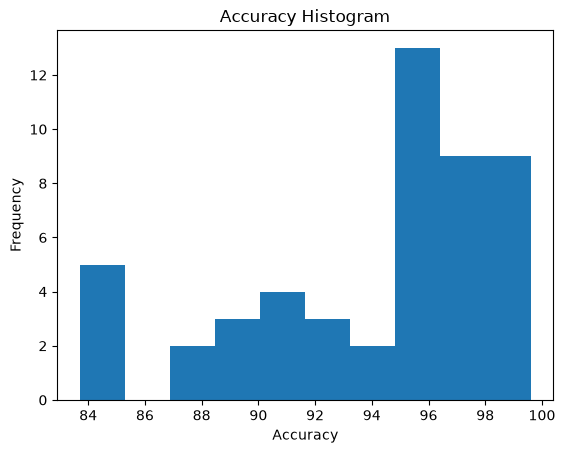

In [ ]:
#Q31
plt.hist(df['Accuracy'])
plt.title('Accuracy Histogram')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

## Question 32

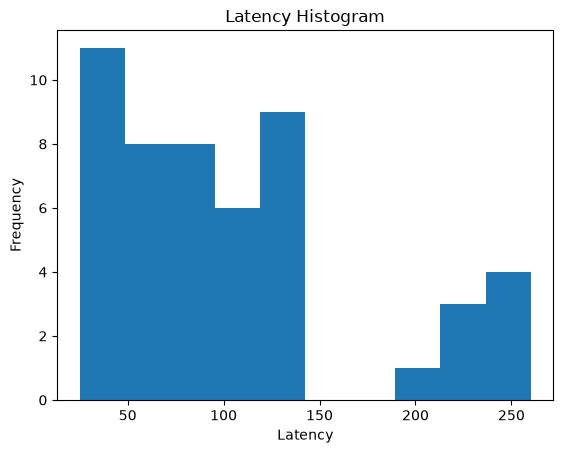

In [ ]:
#Q32
plt.hist(df['InferenceLatency'])
plt.title('Latency Histogram')
plt.xlabel('Latency')
plt.ylabel('Frequency')
plt.show()

## Question 33

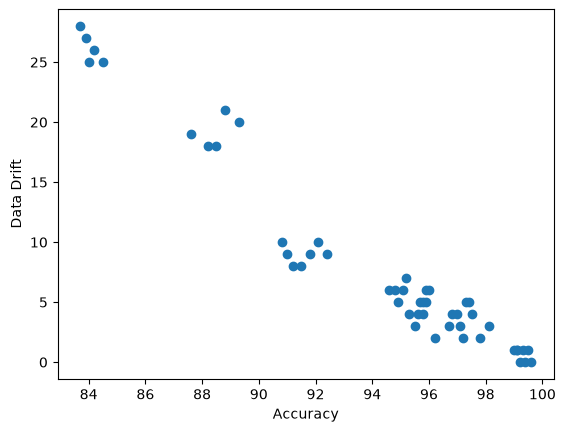

In [ ]:
#Q33
plt.scatter(df['Accuracy'],df['DataDrift'])
plt.xlabel('Accuracy')
plt.ylabel('Data Drift')
plt.show()

## Question 34

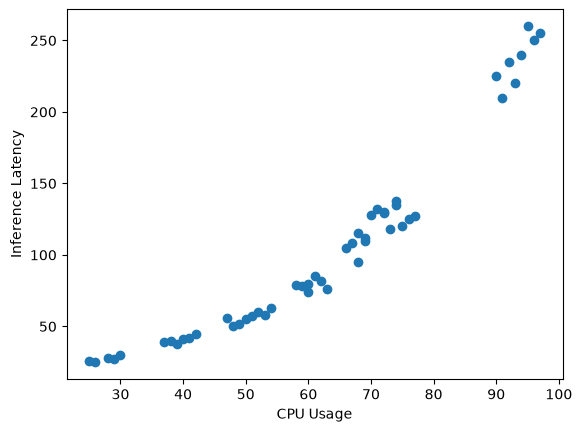

In [ ]:
#Q34
plt.scatter(df['CPUUsage'],df['InferenceLatency'])
plt.xlabel('CPU Usage')
plt.ylabel('Inference Latency')
plt.show()

## Question 35

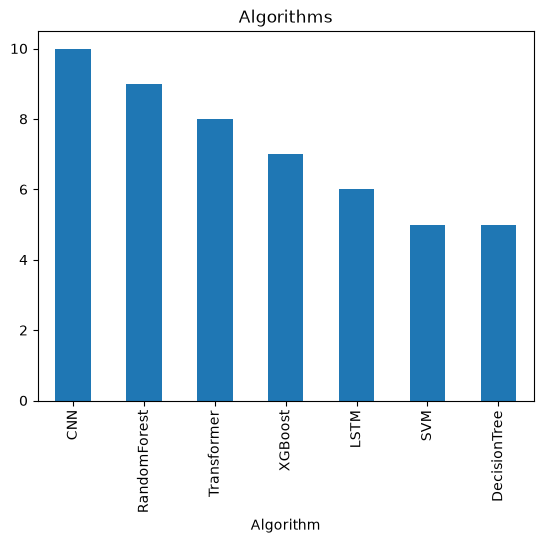

In [ ]:
#Q35
df['Algorithm'].value_counts().plot(kind='bar')
plt.title('Algorithms')
plt.show()

## Question 36

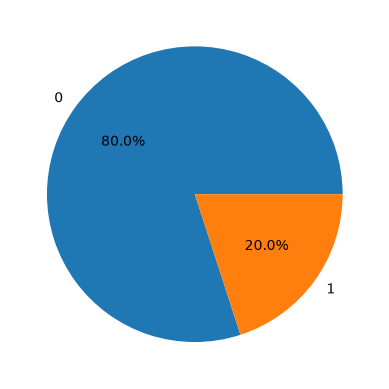

In [ ]:
#Q36
df['FailureRisk'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.show()

## Question 37

In [ ]:
#Q37
le=LabelEncoder()
df['AlgorithmEncoded']=le.fit_transform(df['Algorithm'])
df[['Algorithm','AlgorithmEncoded']].head()

,Algorithm,AlgorithmEncoded
0,RandomForest,3
1,XGBoost,6
2,CNN,0
3,LSTM,2
4,SVM,4


## Question 38

In [ ]:
#Q38
X=df[['AlgorithmEncoded','TrainingSamples','Accuracy','InferenceLatency','DataDrift','CPUUsage','PredictionConfidence']]
y=df['FailureRisk']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Question 39

In [ ]:
#Q39
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
p=rf.predict(X_test)
print(accuracy_score(y_test,p))
print(confusion_matrix(y_test,p))
print(classification_report(y_test,p))

1.0
[[8 0]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## Question 40

In [52]:
#Q40
new=pd.DataFrame({'Algorithm':['Transformer','RandomForest','CNN'],'TrainingSamples':[275000,135000,190000],'Accuracy':[98.4,93.8,96.5],'InferenceLatency':[215,68,145],'DataDrift':[4,12,6],'CPUUsage':[88,54,72],'PredictionConfidence':[0.98,0.92,0.97]});new['AlgorithmEncoded']=le.transform(new['Algorithm']);new['FailureRiskPrediction']=rf.predict(new[['AlgorithmEncoded','TrainingSamples','Accuracy','InferenceLatency','DataDrift','CPUUsage','PredictionConfidence']])
print(new)
print('Recommendation: Deploy low-risk models. Monitor latency, drift and CPU regularly.')

      Algorithm  TrainingSamples  Accuracy  InferenceLatency  DataDrift  \
0   Transformer           275000      98.4               215          4   
1  RandomForest           135000      93.8                68         12   
2           CNN           190000      96.5               145          6   

   CPUUsage  PredictionConfidence  AlgorithmEncoded  FailureRiskPrediction  
0        88                  0.98                 5                      0  
1        54                  0.92                 3                      0  
2        72                  0.97                 0                      0  
Recommendation: Deploy low-risk models. Monitor latency, drift and CPU regularly.
